## INITIALIZATION
useful lines:

with_rx.printSchema()

train_df.select("ENROLID").distinct().count()

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/01 14:44:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/01 14:44:50 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/01 14:44:50 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
2025-11-01 14:44:51,063 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/11/01 14:44:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-11-01 14:44:52,686 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-11-01 14:44:54,404 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-11-01

## Build Pilot IDs

In [3]:
dx_cols = ['DX1', 'DX2', 'DX3', 'DX4', 'PDX']
target_col = ["NETPAY17"]
df_enrollees_cols = ["AGEGRP","SEX","ENROLID","REGION","INDSTRY"]
pilot_stages = [1,2]

def ckd_stage_expr(dx_cols):
    """
    Returns a single Spark expression that gives the CKD stage as
      1-6  … exact stage found
      0    … N189  (unspecified CKD)
      null … no CKD code in any DX column
    """
    # build one expression per DX column
    pieces = []
    for c in dx_cols:
        pieces.append(
    F.when(F.col(c) == "N189", F.lit(0))
     .otherwise(
         F.expr(f"try_cast(regexp_extract({c}, 'N18([1-6]).*', 1) AS int)")
     )
)
    # coalesce from left to right → first non-null wins
    return F.coalesce(*pieces)

In [4]:

year1= 2017
year2= 2018
# ◼︎ B) pull CKD claims in 2017–2018, tag with stage, filter to pilot IDs who have Stage3/4 in BOTH years
df_ckd_2years = (
    df_claims
     .withColumn("YEAR", F.year("SVCDATE"))
     .filter(F.col("YEAR").between(year1,year2))
     .withColumn("CKD_STAGE", ckd_stage_expr(dx_cols))
     .filter(F.col("CKD_STAGE").isNotNull())
)
df_ckd_2years.show(3)
# B1) IDs with Stage3/4 in 2017
ids_year1 = (
    df_ckd_2years
      .filter(F.col("YEAR")==year1)
      .filter(F.col("CKD_STAGE").isin(pilot_stages))
      .select("ENROLID").distinct()
)

# B2) IDs with Stage3/4 in 2018
ids_year2 = (
    df_ckd_2years
      .filter(F.col("YEAR")==year2)
      .filter(F.col("CKD_STAGE").isin(pilot_stages))
      .select("ENROLID").distinct()
)

# B3) Intersection → pilot IDs
pilot_ids = ids_year2.intersect(ids_year1)


#pilot_ids.count()

+----------+--------+-------+----+----+-----+-------+------+----------+-----+----+----------+---+-------+---+-----+-----+------+---+----+----+-----+-------+-------+--------+------+--------+--------+------+----------+----+-------+-------+------+---+-------+----------+-------+----------+------+---+-------+-------+-------+--------+-------+------+-----+-------+------+-------+-------+-------+-------+------+-------+-------+---+---+--------+-------+-------+----------+-----+------+-----------+-------+------+----+-------+-------+-------+-------+------+-------+------+----+-------+-------+------+-------+------+-------+-------+----------+---------+
|   ENROLID|  SEQNUM|VERSION| DX1| DX2|PROC1|PROCTYP|CASEID|   DISDATE|DOBYR|YEAR|   ADMDATE|AGE|CAP_SVC|COB|COINS|COPAY|DEDUCT|DRG| DX3| DX4|DXVER|FACHDID|FACPROF|MHSACOVG|NETPAY|NTWKPROV|PAIDNTWK|   PAY|    PDDATE| PDX|  PPROC|PROCMOD|PROVID|QTY|REVCODE|   SVCDATE|SVCSCAT|   TSVCDAT|ADMTYP|MDC|DSTATUS|STDPLAC|STDPROV|  EFAMID|PLANTYP|REGION|  MSA|DATA

# Load pilot IDs

In [5]:


year1= 2017
year2= 2018
enrol_one = (
    df_enrollment
      .join(pilot_ids, "ENROLID")                 # keep only pilot IDs
      .filter(F.col("YEAR").between(year1, year2))  # keep the two years
      .orderBy(F.col("ENROLID"), F.desc("YEAR"))  # newest row for each ID first
      .dropDuplicates(["ENROLID"])                # keep that first row
      .select(*df_enrollees_cols)                 # drop YEAR automatically
)

# Now enrol_one is exactly one row per ENROLID,
# sourcing its data from 2018 if available, otherwise from 2017.
enrol_one.show(5, truncate=False)
enrol_one.count()

+------+---+--------+------+-------+
|AGEGRP|SEX|ENROLID |REGION|INDSTRY|
+------+---+--------+------+-------+
|4     |1  |27365001|1     |4      |
|5     |1  |27832701|1     |4      |
|5     |1  |27838901|1     |4      |
|5     |2  |27879801|1     |4      |
|5     |2  |27980401|1     |4      |
+------+---+--------+------+-------+
only showing top 5 rows


25/11/01 15:05:10 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/11/01 15:11:45 WARN DAGScheduler: Broadcasting large task binary with size 1171.3 KiB


16466

In [6]:
# ◼︎ C) Pull *all* claims for those pilots in 2017–2018
# needed for cost computation below!!
two_year_claims = (
    df_claims
      .withColumn("YEAR", F.year("SVCDATE"))
      .join(pilot_ids, on="ENROLID", how="inner")
      .filter(F.col("YEAR").between(year1,year2))
      .orderBy("ENROLID","SVCDATE")
)

# actual features computed from only one year of data!!
pilot_claims = (
    two_year_claims
      .filter(F.col("YEAR")==year1)
)


# Cost aggregation

In [7]:
from pyspark.sql import functions as F, Window

# ── 0) Your inflation factors ────────────────────────────────
inflation_map = {
    2017: 1.0,
    2018: 1.0685946832951803,
    2019: 1.1371893665903605
}
# Build a Spark map literal: YEAR → factor
infl_map = sum([[F.lit(year), F.lit(factor)] for year, factor in inflation_map.items()], [])
inflation_expr = F.create_map(*infl_map)


# ── 1) Add inflation‐adjusted cost to the raw claims DF ───────
df_adj_claims = (
    two_year_claims
      .filter(F.col("RX").isNotNull())
      # look up the factor by YEAR
      .withColumn("inflation_factor", inflation_expr[F.col("YEAR")])
      # normalize all costs back to 2017 dollars
      .withColumn("NETPAY17", F.col("NETPAY") / F.col("inflation_factor"))
      # keep everything *and* the new NETPAY17 for later
      .drop("inflation_factor")
)

# Now df_adj_claims is identical to pilot_ckd_claims except it has NETPAY17

In [ ]:
# ── 2) Build the per‐enrollee annual summary ──────────────────
agg_cost = (
    df_adj_claims
      .groupBy("ENROLID", "YEAR")
      .agg(
         F.sum("NETPAY17").alias("annual_cost17"),
      )
)

df_2017 = agg_cost.filter(F.col("YEAR") == 2017)
df_2018 = agg_cost.filter(F.col("YEAR") == 2018)

from pyspark.sql import functions as F

cutoffs = [50000, 75000, 100000, 200000, 300000, 400000, 500000]
colnames_2017 = [f"highcost_gt_{c}_2017" for c in cutoffs]
colnames = [f"highcost_gt_{c}" for c in cutoffs]

# Start with the lowest cutoff
df = df_2017.withColumn(colnames_2017[0], (F.col("annual_cost17") > cutoffs[0]).cast("int"))
df_2018_new = df_2018.withColumn(colnames[0], (F.col("annual_cost17") > cutoffs[0]).cast("int"))

for i in range(1, len(cutoffs)):
    prev = colnames_2017[i-1]
    curr = colnames_2017[i]
    # Only check higher threshold if previous was 1
    df = df.withColumn(curr, ((F.col(prev) == 1) & (F.col("annual_cost17") > cutoffs[i])).cast("int"))
    df_2018_new = df_2018_new.withColumn(curr, ((F.col(prev) == 1) & (F.col("annual_cost17") > cutoffs[i])).cast("int"))

## COLUMN NAMES TO CHANGE  (09162025)
df= (df
.filter(df["annual_cost17"] >= 0)
.filter(df["annual_cost17"].isNotNull())
.drop("YEAR"))

In [13]:
############### creating 0916_2017_18 data for OCT stratificaition
from pyspark.sql.functions import concat_ws, col
df_2018_init =spark.read.format("parquet").load( "0902_adherence_income_info.parquet")
df_2018_init = (df_2018_init.filter(df_2018_init["annual_cost17"] > -1)
.filter(df_2018_init["annual_cost17"].isNotNull())
.drop("YEAR","cost_stratum_2018",'first_nephrology_date','first_ckd_date',
 'total_ckd_cost_2017', '2017Q1',
 '2017Q2',
 '2017Q3',
 '2017Q4',
 'cost_stratum_2017',
))
df_2018_init = df_2018_init.withColumnRenamed("annual_cost17", "annual_cost_2018_deflated")



df_merged = (df    
        .join(df_2018_init, on="ENROLID", how="inner")   # inner keeps only pilot IDs
)
print(df_merged.columns)

# 33551 unique enrollees
df_merged.write.mode("overwrite").parquet("0916_2017_18_with_2017_cost.parquet")




25/09/17 10:52:00 WARN DAGScheduler: Broadcasting large task binary with size 1051.4 KiB


['ENROLID', 'annual_cost_2017', 'highcost_gt_50000_2017', 'highcost_gt_75000_2017', 'highcost_gt_100000_2017', 'highcost_gt_200000_2017', 'highcost_gt_300000_2017', 'highcost_gt_400000_2017', 'highcost_gt_500000_2017', 'INCOME_LEVEL', 'annual_cost_2018_deflated', 'highcost_gt_50000', 'highcost_gt_75000', 'highcost_gt_100000', 'highcost_gt_200000', 'highcost_gt_300000', 'highcost_gt_400000', 'highcost_gt_500000', 'AGEGRP', 'SEX', 'REGION', 'has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia', 'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism', 'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea', 'stage_2017', 'util_2017', 'THRCLS_53', 'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47', 'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_max_ckd_stage', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_

25/09/17 11:04:39 WARN DAGScheduler: Broadcasting large task binary with size 1051.4 KiB
25/09/17 11:04:46 WARN DAGScheduler: Broadcasting large task binary with size 1173.6 KiB
25/09/17 11:04:47 WARN DAGScheduler: Broadcasting large task binary with size 1481.3 KiB


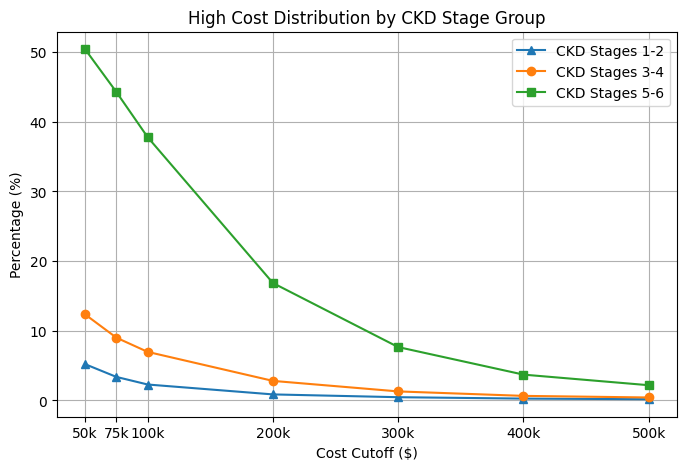

In [44]:
import matplotlib.pyplot as plt

# Cost cutoffs
cutoffs = [50000, 75000, 100000, 200000, 300000, 400000, 500000]

# Percentages for the three CKD stage groups
stages_3_4 = [12.35, 9.01, 6.97, 2.81, 1.30, 0.66, 0.43]
stages_5_6 = [50.40, 44.26, 37.77, 16.85, 7.66, 3.71, 2.19]
stages_1_2 = [5.21, 3.38, 2.29, 0.87, 0.47, 0.27, 0.18]

# Plot
plt.figure(figsize=(8,5))
plt.plot(cutoffs, stages_1_2, marker='^', label='CKD Stages 1-2')
plt.plot(cutoffs, stages_3_4, marker='o', label='CKD Stages 3-4')
plt.plot(cutoffs, stages_5_6, marker='s', label='CKD Stages 5-6')

plt.xlabel("Cost Cutoff ($)")
plt.ylabel("Percentage (%)")
plt.title("High Cost Distribution by CKD Stage Group")
plt.legend()
plt.grid(True)
labels = ["50k", "75k", "100k", "200k", "300k", "400k", "500k"]

plt.xticks(cutoffs, labels)  # set cutoffs as positions, labels as ticks
plt.show()


In [23]:
df.write.mode("overwrite").parquet("df_0827_2017_18_highcost_cutoffs.parquet")


# Track CKD stage quarterly

In [9]:
from itertools   import product

# ── 0) pick the calendar window you care about ────────────────
years     = [year1]         # <-- put the real years here
quarters  = [1, 2, 3, 4]
yq_labels = [f"{y}Q{q}" for y, q in product(years, quarters)]

# ── 1) keep only 2018 CKD claims and stamp QUARTER ────────────────
df_q = (pilot_claims
        .withColumn("CKD_STAGE", ckd_stage_expr(dx_cols))
        .withColumn("QUARTER", F.quarter("SVCDATE"))
        .select("ENROLID", "YEAR","QUARTER","SVCDATE", "CKD_STAGE")

)
#df_q.select("CKD_STAGE").distinct().count() ## prints 8 (0715)

In [10]:
w_q = (Window
       .partitionBy("ENROLID", "YEAR", "QUARTER")
       .orderBy(F.col("SVCDATE").desc()))

df_recent = (df_q
        .filter((F.col("CKD_STAGE").isNotNull()) & (F.col("CKD_STAGE") > 0))          # toss rows where stage is -1, 0, or null
        .withColumn("rn", F.row_number().over(w_q))
        .filter("rn = 1")                        # latest valid in quarter
        .select("ENROLID", "YEAR", "QUARTER", "CKD_STAGE"))
         
# ── 3) pivot wide: 2018Q1…2018Q4 as columns ─────────────────
df_stage_pivot = (df_recent
    .withColumn("YQ", F.concat_ws("Q", F.col("YEAR"), F.col("QUARTER")))
    .groupBy("ENROLID")
    .pivot("YQ", yq_labels)                           # preserves Q-order
    .agg(F.first("CKD_STAGE"))
)

# ── 5) cast every pivoted column to int, -1 = “no CKD yet” ──
for col in yq_labels:
    df_stage_pivot = df_stage_pivot.withColumn(
        col,
        F.when(F.col(col).isNull(), F.lit(-1)).otherwise(F.col(col).cast("int"))
    )

# ── 5) add “dominant” stage_2018 = most-recent quarter value ─
df_stage_pivot = df_stage_pivot.withColumn(
    "stage_2017", ## FAKE 2017 data
    F.coalesce(                                   # Q4 first, then Q3…
        *[F.when(F.col(f"2017Q{q}") != -1, F.col(f"2017Q{q}"))
          for q in [4, 3, 2, 1]]
    ).cast("int")
)
#df_stage_pivot.show(5)       # one row per enrollee, CKD stage per quarter (–1 = none)

# 1) grab the offending rows
null_2017 = df_stage_pivot.filter( F.col("stage_2017").isNull() )

In [12]:
df_diag = df_stage_pivot.withColumns(
    {f"{y}_has_CKD": reduce(
         lambda a, b: a | b,
         [F.col(f"{y}Q{q}") != -1 for q in quarters]
     )
     for y in years}
)


df_stage_pivot_clean = df_diag.filter(
    F.expr(" and ".join([f"{y}_has_CKD" for y in years]))
).drop(*[f"{y}_has_CKD" for y in years])
df_stage_pivot_clean.columns

['ENROLID', '2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017']

### If doing 2018 instead 2017 data, careful with column names!

In [ ]:
# ── 5) add “dominant” stage_2018 = most-recent quarter value ─
df_stage_pivot = df_stage_pivot.withColumn(
    "stage_2017", ## FAKE 2017 data
    F.coalesce(                                   # Q4 first, then Q3…
        *[F.when(F.col(f"2017Q{q}") != -1, F.col(f"2017Q{q}"))
          for q in [4, 3, 2, 1]]
    ).cast("int")
)
#df_stage_pivot.show(5)       # one row per enrollee, CKD stage per quarter (–1 = none)

# 1) grab the offending rows
null_2017 = df_stage_pivot.filter( F.col("stage_2017").isNull() )
null_2017.show(10, truncate=False)
#print("Rows with stage_2017 = null:", null_2017.count())

In [11]:
# 1. Define old and new column names
old_cols = [f"{y}Q{q}" for y in years for q in [1, 2, 3, 4]]
new_cols = [f"{y-1}Q{q}" for y in years for q in [1, 2, 3, 4]]

# 2. Create a renamed version of df_stage_pivot
for old, new in zip(old_cols, new_cols):
    df_stage_pivot = df_stage_pivot.withColumnRenamed(old, new)

# Optional: verify
df_stage_pivot.show(5)

+-----------+------+------+------+------+----------+
|    ENROLID|2017Q1|2017Q2|2017Q3|2017Q4|stage_2017|
+-----------+------+------+------+------+----------+
| 2687114401|     4|     6|     5|     4|         4|
|33142058701|     3|     3|     3|    -1|         3|
| 1469126402|     3|     3|     3|     3|         3|
| 3062436801|     3|     3|     3|     2|         2|
| 4113918701|    -1|     3|     3|     3|         3|
+-----------+------+------+------+------+----------+
only showing top 5 rows


# Get CKD-related comorbidities and one-hot encode these
Explodes all ICD‐10 Dx columns from your pilot_claims DataFrame.

Filters out any CKD codes (N18xx).

Counts the frequency of each remaining raw code.

Keeps only the top raw codes you care about (say the top 50).

Maps each raw code into your clinical “bucket” (falling back to the raw code if unmapped).

Aggregates bucket counts and pulls out the top 10 buckets.

In [14]:
df_exploded = (
    pilot_claims
      .select("ENROLID", *dx_cols)
      .withColumn("raw_code", F.explode(F.array(*[F.col(c) for c in dx_cols])))
      .filter(F.col("raw_code").isNotNull())
)

# 3) Filter out any N18xx (CKD) codes
df_filtered = df_exploded.filter(~F.col("raw_code").startswith("N18"))

# 4) Count raw_code frequencies and keep top K (e.g. 50)
top_raw = (
    df_filtered
      .groupBy("raw_code")
      .count()
      .orderBy(F.desc("count"))
      .limit(50)
)

# 5) Bring that list back to filter & bucket
top_codes = [row["raw_code"] for row in top_raw.collect()]
print("Top codes; ", top_codes)
df_top = df_filtered.filter(F.col("raw_code").isin(top_codes))

# 6) Define your grouping map (example buckets)
code_map = {
    "D631": "Anemia",
    "D509": "Anemia",
    "D649": "Anemia",

    "I10":  "Hypertension",
    "I129": "Hypertension",
    "I130": "Hypertension",
    "E1122":"Type 2 Diabetes",
    "E1121":"Type 2 Diabetes",
    "E1165":"Type 2 Diabetes",

    "E119": "Type 2 Diabetes",
    "E559": "Vitamin D Deficiency",
    "R809": "Proteinuria",
    "E785": "Hyperlipidemia",
    "E782": "Hyperlipidemia",
    "N2581":"Hyperparathyroidism",
    "N179": "Acute Kidney Failure",
    "Z940": "Kidney Transplant",
    "Z79899":"Long-term Drug Therapy",
    "E039": "Hypothyroidism",
    "G4733": "Sleep Apnea"
}
mapping_expr = F.create_map(*[F.lit(x) for kv in code_map.items() for x in kv])

# 7) Assign buckets (fallback to raw_code)
df_bucketed = df_top.withColumn(
    "bucket",
    F.coalesce(
      mapping_expr.getItem(F.col("raw_code")),
      F.col("raw_code")
    )
)



Top codes;  ['I10', 'E119', 'E785', 'I129', 'E1122', 'N179', 'D631', 'D649', 'E559', 'Z940', 'E1165', 'D509', 'Z79899', 'G4733', 'E039', 'I130', 'E782', 'A419', 'I2510', 'Z0000', 'N2581', 'R809', 'M545', 'E6601', 'E669', 'N390', 'Z23', 'E1121', 'E11621', 'I120', 'Z992', 'E872', 'D689', 'R079', 'E875', 'I509', 'I214', 'C9000', 'R0602', 'E1140', 'Z01818', 'J189', 'K219', 'M542', 'E860', 'M109', 'E7800', 'N200', 'Z794', 'E1142']


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/pyspark/sql/classic/column.py:359: FutureWarning: A column as 'key' in getItem is deprecated as of Spark 3.0, and will not be supported in the future release. Use `column[key]` or `column.key` syntax instead.
  warnings.warn(


In [15]:
# 8) Count buckets and pull top 10
top10_buckets = (
    df_bucketed
      .groupBy("bucket")
      .count()
      .orderBy(F.desc("count"))
      .limit(10)
)

top10_buckets.show(truncate=False)


+----------------------+------+
|bucket                |count |
+----------------------+------+
|Hypertension          |746463|
|Type 2 Diabetes       |524844|
|Anemia                |363416|
|Hyperlipidemia        |268894|
|Acute Kidney Failure  |166431|
|Vitamin D Deficiency  |104551|
|Kidney Transplant     |97792 |
|Long-term Drug Therapy|87873 |
|Sleep Apnea           |81276 |
|Hypothyroidism        |81231 |
+----------------------+------+



In [16]:
top10_buckets_2017 = [
    "Hypertension",
    "Type 2 Diabetes",
    "Anemia",
    "Hyperlipidemia",
    "Acute Kidney Failure",
    "Hyperparathyroidism",
    "Kidney Transplant",
    "Vitamin D Deficiency",
    "Long-term Drug Therapy",
    "Hypothyroidism","Sleep Apnea"
]


In [17]:
from pyspark.sql import functions as F

# 1) Collect the top-10 bucket names into a Python list
#top10_list = [row["bucket"] for row in top10_buckets.collect()]

# 2) Filter your bucketed DataFrame to only those top-10
df_top10 = df_bucketed.filter(F.col("bucket").isin(top10_buckets_2017))

# 3) For each ENROLID and bucket, flag presence once
df_flag = (
    df_top10
      .select("ENROLID", "bucket")
      .dropDuplicates()               # one row per enrollee‐bucket
      .withColumn("has_flag", F.lit(1))
)

# 4) Pivot wide so each bucket becomes its own binary column
df_diagnoses = (
    df_flag
      .groupBy("ENROLID")
      .pivot("bucket", top10_buckets_2017)    # ensure consistent column order
      .agg(F.first("has_flag"))
      .fillna(0)                      # missing ⇒ 0
)

# 5) (Optional) rename columns more prettily
for b in top10_buckets_2017:
    df_diagnoses = df_diagnoses.withColumnRenamed(b, f"has_{b.replace(' ','_')}")

# 6) Now df_features has one row per ENROLID and 10 columns of 0/1 flags
df_diagnoses.show(5)


+---------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------+------------------+---------------+
|  ENROLID|has_Hypertension|has_Type_2_Diabetes|has_Anemia|has_Hyperlipidemia|has_Acute_Kidney_Failure|has_Hyperparathyroidism|has_Kidney_Transplant|has_Vitamin_D_Deficiency|has_Long-term_Drug_Therapy|has_Hypothyroidism|has_Sleep_Apnea|
+---------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------+------------------+---------------+
|131734201|               1|                  0|         1|                 0|                       0|                      0|                    0|                       0|                         0|                 0|              0|
|604626901|               0|                  1|    

# Join static df with diagnoses, cost, and CKD stages

In [18]:
df_enrol_with_feats = (
    enrol_one                # your one-row-per-ENROLID+YEAR
      .join(df_diagnoses, "ENROLID", how="left")
      .fillna({f"has_{b.replace(' ','_')}": 0 for b in top10_buckets_2017})
)

df_enrol_with_feats.show(5)
print(df_enrol_with_feats.select("ENROLID").distinct().count())



+--------+------+---+------+-------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------+------------------+---------------+
| ENROLID|AGEGRP|SEX|REGION|INDSTRY|has_Hypertension|has_Type_2_Diabetes|has_Anemia|has_Hyperlipidemia|has_Acute_Kidney_Failure|has_Hyperparathyroidism|has_Kidney_Transplant|has_Vitamin_D_Deficiency|has_Long-term_Drug_Therapy|has_Hypothyroidism|has_Sleep_Apnea|
+--------+------+---+------+-------+----------------+-------------------+----------+------------------+------------------------+-----------------------+---------------------+------------------------+--------------------------+------------------+---------------+
|  602902|     5|  2|     2|      7|               0|                  1|         1|                 1|                       0|                      1|                    0|                       1|               

In [19]:

df_utilization = (
    pilot_claims
      .groupBy("ENROLID")
      .agg(F.count("ENROLID").alias("util_2017"))
)

#df_utilization.show(5, truncate=False)


In [20]:
# join keys
keys = ["ENROLID"]

#assert df_enrol_with_feats.select("ENROLID").distinct().count() == df_enrol_with_feats.count()
#assert df_stage_pivot.select("ENROLID").distinct().count() == df_stage_pivot.count()
#assert df_cost_stratum.select("ENROLID").distinct().count() == df_cost_stratum.count()
#assert df_utilization.select("ENROLID").distinct().count() == df_utilization.count()

df_full = (
    df_enrol_with_feats
      .join(df_stage_pivot, on=keys, how="inner") # stage of CKD by quarter
      .join(df_cost_stratum, on=keys, how="inner")
      .join(df_utilization,on=keys,how="inner"))

df_full.count()

33590

# Medications

In [27]:
df_rx_claims = (
    df_claims                      # ←  your full claims table
        .filter(F.col("CLAIM_TYPE") == "RX")
        .filter(F.col("YEAR")==year1)
        .join(df_utilization, on="ENROLID", how="inner")   # inner keeps only pilot IDs
)
df = (
    df_rx_claims
    .groupBy("THERCLS")
    .agg(F.count("*").alias("nrows"))
)
year1

2017

In [28]:
top10_thercls = df.orderBy("nrows", ascending=False).select("THERCLS","nrows").limit(10).toPandas()
# ── 0) Grab the class names as a Python list ───────────────────
top_classes = top10_thercls["THERCLS"].tolist()      # already a pandas DF
top_classes

[Decimal('53'),
 Decimal('51'),
 Decimal('52'),
 Decimal('47'),
 Decimal('69'),
 Decimal('46'),
 Decimal('172'),
 Decimal('174'),
 Decimal('60'),
 Decimal('181')]

In [29]:

# ── 1) Keep only RX claims from pilot IDs *and* those classes ──
df_rx_top = (
    df_rx_claims                            # from earlier join
        .filter(F.col("THERCLS").isin(top_classes))
        .select("ENROLID", "THERCLS")          # no other cols needed
        .distinct()                            # one row per (ENROLID, class)
)

# ── 2) Pivot to wide form: 10 columns, 1/0 flags ───────────────
df_flags = (
    df_rx_top
        .withColumn("flag", F.lit(1))
        .groupBy("ENROLID")
        .pivot("THERCLS", top_classes)         # keeps column order stable
        .agg(F.max("flag"))
        .na.fill(0)                            # any missing->0
)

def make_safe(code):
    """
    Turn a numeric or string code into a Spark-legal column label.
      • Cast to string
      • Replace dots/whitespace/punctuation with '_'               (12.34 → '12_34')
    """
    # Convert 12.0 → '12' so we don’t get trailing '.0'
    if isinstance(code, float) and code.is_integer():
        code = int(code)
    return re.sub(r'\W+', '_', str(code).strip())

# ── Rename the pivoted columns ---------------------------------------------
rename_exprs = (
    [F.col("ENROLID")] +
    [
        F.col(f"`{c}`").alias(f"THRCLS_{make_safe(c)}")
        for c in top_classes          # numeric codes taken straight from your list
    ]
)

df_flags_prefixed = df_flags.select(*rename_exprs)


In [30]:
df_flags_prefixed.count()
# ── Join back to the pilot cohort ------------------------------------------
df_full_with_meds = (
    df_full
        .join(df_flags_prefixed, on="ENROLID", how="left")
        .na.fill(0)
)
df_full_with_meds.count()

33590

In [ ]:
#assert df_full.count() == df_full_with_meds.count()

df_full_with_meds.write.mode("overwrite").parquet("df_0714_2017_18_with_THERCLS.parquet")